In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/SYPBLproject


In [ ]:
# =============================================
# ✅ INDIAN CURRENCY NOTE CLASSIFICATION - PREPROCESSING
# =============================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [ ]:
# # =============================================
# # 1️⃣ DATASET SETUP
# # =============================================
# dataset_path = "/content/drive/MyDrive/SYPBLproject/indian_currency"

In [ ]:
# # Use your original folder names exactly
# CATEGORIES = ["FAKE 500", "FAKE 500  AUGUMENTED", "REAL 500", "real 500 AUGUMENTED"]
# IMG_SIZE = 128

# data = []
# labels = []

In [ ]:
# =============================================
# 1️⃣ DATASET SETUP
# =============================================
dataset_path = "/content/drive/MyDrive/SYPBLproject/indian_currency"

# All dataset folders (both real and fake, including augmented)
CATEGORIES = ["FAKE 500", "FAKE 500  AUGUMENTED", "REAL 500", "real 500 AUGUMENTED"]
IMG_SIZE = 128

data = []
labels = []

In [ ]:
# =============================================
# 2️⃣ LOAD IMAGES AND ASSIGN LABELS (0 = FAKE, 1 = REAL)
# =============================================
for category in CATEGORIES:
    folder = os.path.join(dataset_path, category)
    if not os.path.exists(folder):
        print(f"⚠️ Folder not found: {folder}")
        continue

    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # Assign label
            if "FAKE" in category.upper():
                labels.append(0)  # fake
            else:
                labels.append(1)  # real

            data.append(img)
        except:
            pass  # skip unreadable images

data = np.array(data)
labels = np.array(labels)

print("✅ Data Loaded Successfully")
print("Total Images:", len(data))
print("Data Shape:", data.shape)
print("Labels Shape:", labels.shape)
print(f"Fake notes: {(labels == 0).sum()} | Real notes: {(labels == 1).sum()}")

✅ Data Loaded Successfully
Total Images: 919
Data Shape: (919, 128, 128)
Labels Shape: (919,)
Fake notes: 396 | Real notes: 523


In [ ]:
# data = np.array(data)
# labels = np.array(labels)


In [ ]:
# print("✅ Data Loaded Successfully")
# print("Total Images:", len(data))
# print("Data Shape:", data.shape)
# print("Labels Shape:", labels.shape)

✅ Data Loaded Successfully
Total Images: 919
Data Shape: (919, 128, 128)
Labels Shape: (919,)


In [ ]:
# =============================================
# 3️⃣ DATA AUGMENTATION (optional – to balance dataset)
# =============================================
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)


In [ ]:
data = data[..., np.newaxis] / 255.0  # normalize and add channel dimension

In [ ]:
# for idx, img in enumerate(data):
#     # ✅ Fix dimension issue
#     if img.ndim == 2:
#         img_exp = np.expand_dims(img, axis=(0, -1))  # (1,128,128,1)
#     else:
#         img_exp = np.expand_dims(img, axis=0)  # (1,128,128,1)

#     i = 0
#     for batch in datagen.flow(img_exp, batch_size=1):
#         augmented_images.append(batch[0])
#         augmented_labels.append(labels[idx])
#         i += 1
#         if i >= 2:  # number of augmentations per image
#             break

In [ ]:
# augmented_images = np.array(augmented_images)
# augmented_labels = np.array(augmented_labels)

In [ ]:
# # ✅ Combine original + augmented data
# if data.ndim == 3:  # (N,128,128)
#     data = np.expand_dims(data, axis=-1)  # (N,128,128,1)

# data = np.concatenate([data, augmented_images])
# labels = np.concatenate([labels, augmented_labels])

In [ ]:
# print("✅ Augmentation Complete")
# print("New Data Shape:", data.shape)
# print("New Labels Shape:", labels.shape)

✅ Augmentation Complete
New Data Shape: (8271, 128, 128, 1)
New Labels Shape: (8271,)


In [ ]:
# =============================================
# 4️⃣ TRAIN-TEST SPLIT
# =============================================
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels
)

In [ ]:
print("\n✅ DATASET SUMMARY")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)



✅ DATASET SUMMARY
Training samples: 735
Testing samples: 184
X_train shape: (735, 128, 128, 1)
y_train shape: (735,)


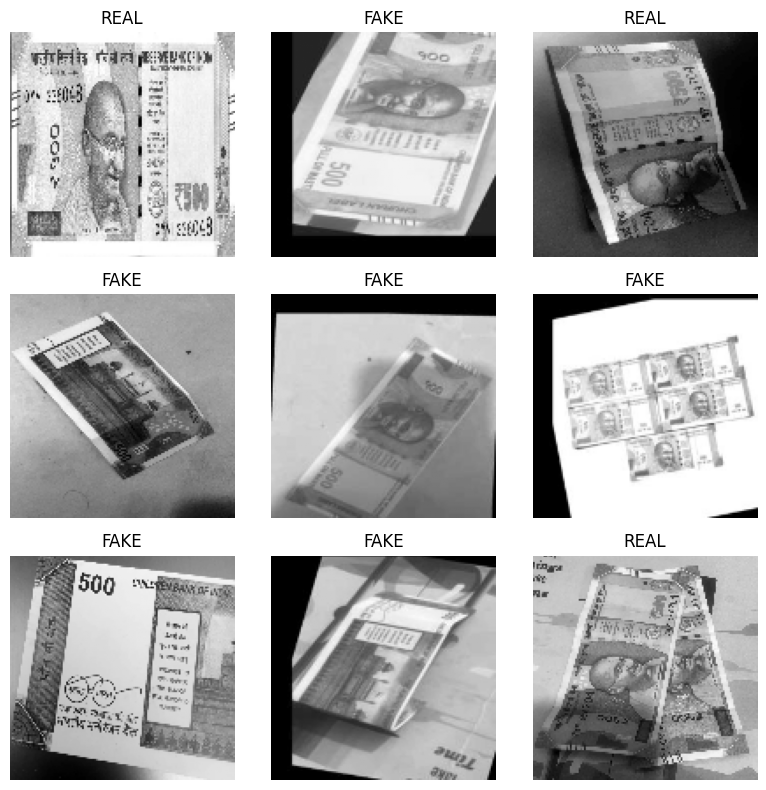

In [ ]:
# =============================================
# 5️⃣ VISUALIZE SOME SAMPLES
# =============================================
plt.figure(figsize=(8, 8))
for i in range(9):
    idx = np.random.randint(0, len(X_train))
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[idx].reshape(128, 128), cmap='gray')
    plt.title("FAKE" if y_train[idx] == 0 else "REAL")
    plt.axis("off")
plt.tight_layout()
plt.show()

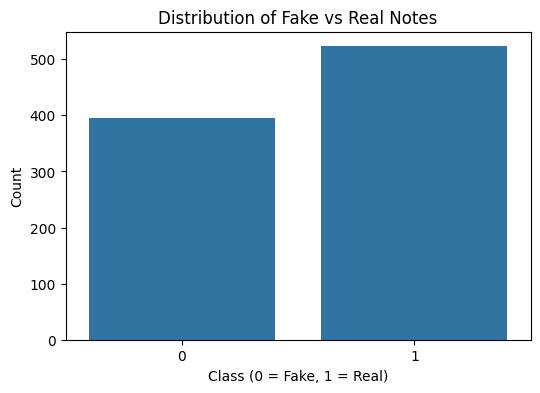

In [ ]:
# =============================================
# 📊 VISUALIZE DATA DISTRIBUTION (Histogram)
# =============================================
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=labels)
plt.title("Distribution of Fake vs Real Notes")
plt.xlabel("Class (0 = Fake, 1 = Real)")
plt.ylabel("Count")
plt.show()

In [ ]:
# # =============================================
# # 4️⃣ NORMALIZATION
# # =============================================
# data = data / 255.0
# labels_cat = to_categorical(labels, num_classes=len(CATEGORIES))


In [ ]:
# # =============================================
# # 5️⃣ TRAIN-TEST SPLIT
# # =============================================
# X_train, X_test, y_train, y_test = train_test_split(
#     data, labels_cat, test_size=0.2, random_state=42, stratify=labels
# )


In [ ]:
# print("\n✅ DATASET SUMMARY")
# print("Training samples:", X_train.shape[0])
# print("Testing samples:", X_test.shape[0])
# print("X_train shape:", X_train.shape)
# print("y_train shape:", y_train.shape)


✅ DATASET SUMMARY
Training samples: 6616
Testing samples: 1655
X_train shape: (6616, 128, 128, 1)
y_train shape: (6616, 4)


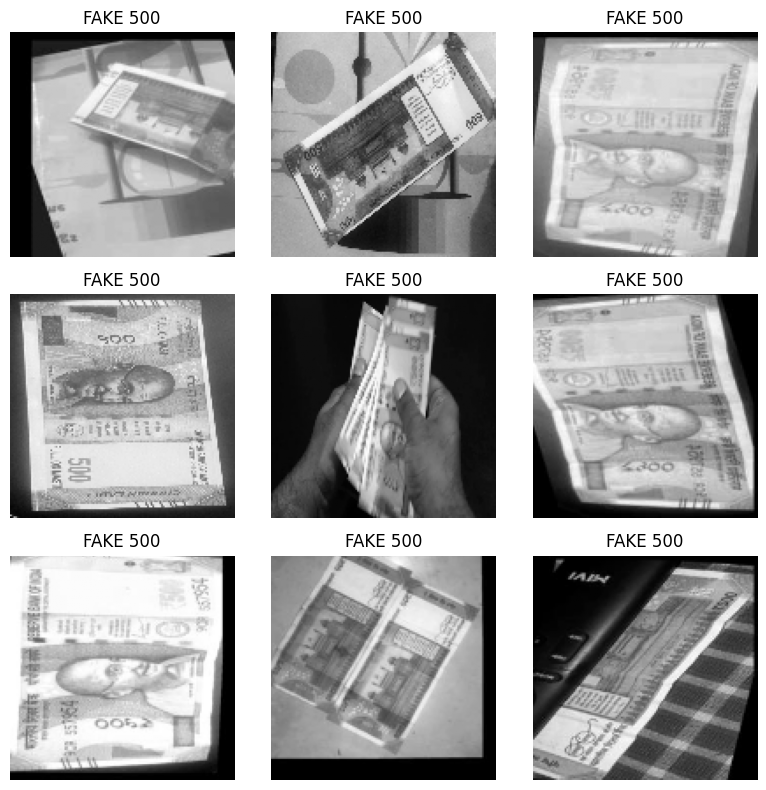

In [ ]:
# # =============================================
# # 6️⃣ VISUALIZE SOME SAMPLES
# # =============================================
# plt.figure(figsize=(8, 8))
# for i in range(9):
#     idx = np.random.randint(0, len(X_train))
#     plt.subplot(3, 3, i + 1)
#     plt.imshow(X_train[idx].reshape(128, 128), cmap='gray')
#     plt.title(f"{CATEGORIES[np.argmax(y_train[idx])]}")
#     plt.axis("off")
# plt.tight_layout()
# plt.show()

In [ ]:
# # ----------------------------
# # STEP 4: Split and Normalize
# # ----------------------------
# from sklearn.model_selection import train_test_split

# # Split into train/test
# X_train, X_test, y_train, y_test = train_test_split(
#     data, labels, test_size=0.2, random_state=42, stratify=labels)

# # Normalize pixel values
# X_train = X_train / 255.0
# X_test = X_test / 255.0

# print("Train shape:", X_train.shape)
# print("Test shape:", X_test.shape)


Train shape: (6616, 128, 128, 1)
Test shape: (1655, 128, 128, 1)


In [ ]:
# # ----------------------------
# # STEP 5: Build CNN Model
# # ----------------------------
# import tensorflow as tf
# from tensorflow.keras import layers, models

# model = models.Sequential([
#     layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
#     layers.MaxPooling2D(2,2),

#     layers.Conv2D(64, (3,3), activation='relu'),
#     layers.MaxPooling2D(2,2),

#     layers.Conv2D(128, (3,3), activation='relu'),
#     layers.MaxPooling2D(2,2),

#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(2, activation='softmax')  # 2 classes: real/fake
# ])

# model.compile(optimizer='adam',
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])

# model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,322 (12.60 MB)

 Trainable params: 3,304,322 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# # ----------------------------
# # STEP 6: Train CNN
# # ----------------------------
# history = model.fit(
#     X_train, y_train,
#     epochs=15,
#     batch_size=32,
#     validation_data=(X_test, y_test)
# )


Epoch 1/15


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipyker

In [ ]:
# =============================================
# 🧠 CNN MODEL TRAINING
# =============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

# Train model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.5474 - loss: 0.7968 - val_accuracy: 0.5707 - val_loss: 0.6751
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 995ms/step - accuracy: 0.5797 - loss: 0.6864 - val_accuracy: 0.5707 - val_loss: 0.6433
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 40s 960ms/step - accuracy: 0.5722 - loss: 0.6643 - val_accuracy: 0.6576 - val_loss: 0.6556
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 956ms/step - accuracy: 0.6192 - loss: 0.6431 - val_accuracy: 0.7011 - val_loss: 0.6193
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 946ms/step - accuracy: 0.6575 - loss: 0.6144 - val_accuracy: 0.6685 - val_loss: 0.6091
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 40s 916ms/step - accuracy: 0.7044 - loss: 0.5548 - val_accuracy: 0.6848 - val_loss: 0.5444
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7543 - loss: 0.5027 - val_accuracy: 0.7228 - val_loss: 0.5686
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 928ms/step - accuracy: 0.7676 - loss: 0.4666 - val_accuracy: 

In [ ]:
# =============================================
# 💾 SAVE MODEL
# =============================================
model.save("/content/drive/MyDrive/SYPBLproject/fake_currency_cnn.h5")
print("✅ Model saved successfully!")


✅ Model saved successfully!


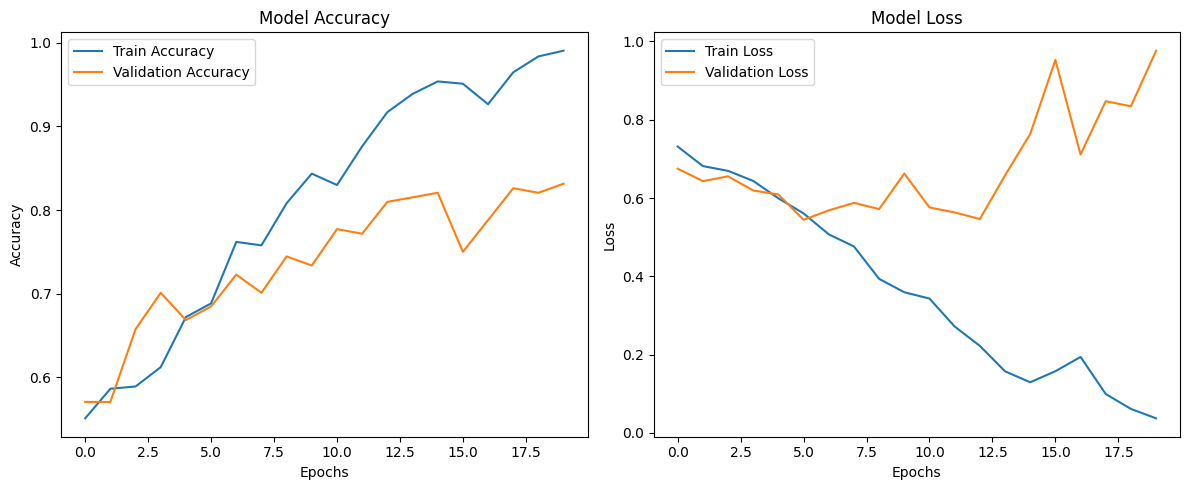

In [ ]:
# =============================================
# 📈 TRAINING PERFORMANCE PLOTS
# =============================================
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 443ms/step


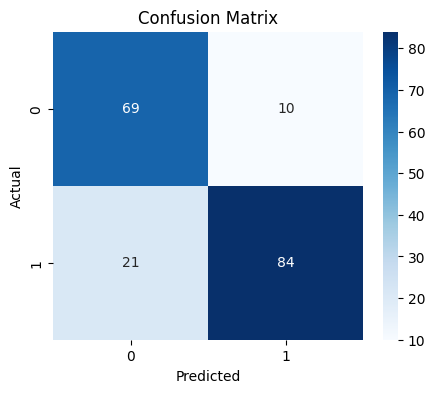


Classification Report:
               precision    recall  f1-score   support

        Fake       0.77      0.87      0.82        79
        Real       0.89      0.80      0.84       105

    accuracy                           0.83       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.83      0.83       184



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict on test set
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Fake', 'Real']))


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# === Function to Predict Fake vs Real ===
def predict_currency_note(model, img_path):
    # Load and preprocess the image
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128))  # same as your training size
    img = img / 255.0                  # normalize
    img = np.expand_dims(img, axis=-1) # add channel dimension
    img = np.expand_dims(img, axis=0)  # add batch dimension

    # Predict
    prediction = model.predict(img)
    pred_class = (prediction > 0.5).astype("int")[0][0]

    # Display result
    label = "REAL NOTE 💰" if pred_class == 1 else "FAKE NOTE ⚠️"
    confidence = float(prediction[0][0]) * 100 if pred_class == 1 else (100 - float(prediction[0][0]) * 100)

    plt.imshow(cv2.imread(img_path))
    plt.title(f"{label} (Confidence: {confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    return label, confidence


In [ ]:
# === Function to Predict Fake vs Real ===
def predict_currency_note(model, img_path):
    # Load and preprocess the image
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128))  # same as your training size
    img = img / 255.0                  # normalize
    img = np.expand_dims(img, axis=-1) # add channel dimension
    img = np.expand_dims(img, axis=0)  # add batch dimension

In [ ]:
img_path = "/content/drive/MyDrive/SYPBLproject/t.jpeg"


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


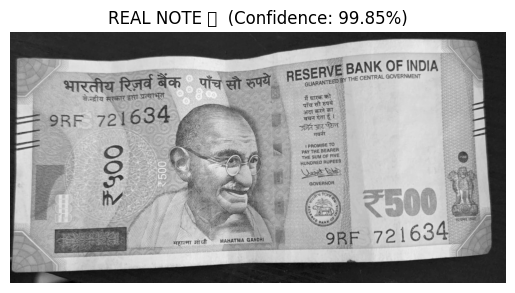

Prediction Result → REAL NOTE 💰 | Confidence: 99.85%


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_currency_note(model, img_path):
    # Load and preprocess image
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # 👈 force grayscale
    img_resized = cv2.resize(img, (128, 128))
    img_norm = img_resized / 255.0
    img_input = np.expand_dims(img_norm, axis=-1)   # add channel dimension (1)
    img_input = np.expand_dims(img_input, axis=0)   # batch dimension

    # Predict
    prediction = model.predict(img_input)
    pred_class = (prediction > 0.5).astype("int")[0][0]

    # Label + confidence
    if pred_class == 1:
        label = "REAL NOTE 💰"
        confidence = float(prediction[0][0]) * 100
    else:
        label = "FAKE NOTE ⚠️"
        confidence = (1 - float(prediction[0][0])) * 100

    # Show image + result
    plt.imshow(img, cmap='gray')
    plt.title(f"{label}  (Confidence: {confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    return label, confidence

# 🧠 Run prediction again
img_path = "/content/drive/MyDrive/SYPBLproject/t.jpeg"
label, confidence = predict_currency_note(model, img_path)
print(f"Prediction Result → {label} | Confidence: {confidence:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


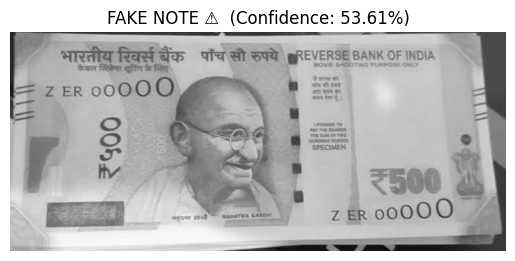

Prediction Result → FAKE NOTE ⚠️ | Confidence: 53.61%


In [ ]:
# 🧠 Run prediction again
img_path = "/content/drive/MyDrive/SYPBLproject/t3.jpeg"
label, confidence = predict_currency_note(model, img_path)
print(f"Prediction Result → {label} | Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


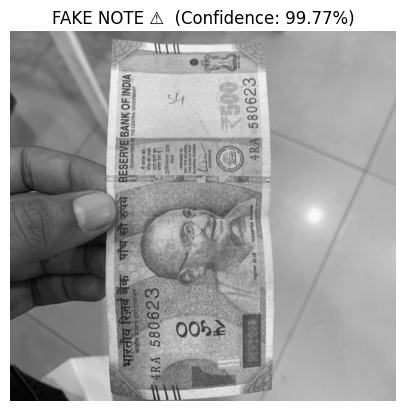

Prediction Result → FAKE NOTE ⚠️ | Confidence: 99.77%


In [ ]:
# 🧠 Run prediction again
img_path = "/content/drive/MyDrive/SYPBLproject/t4.jpeg"
label, confidence = predict_currency_note(model, img_path)
print(f"Prediction Result → {label} | Confidence: {confidence:.2f}%")

In [ ]:
################CNN Trained   #################

In [ ]:
#############API###########

In [ ]:
# Run this cell (copy-paste into a code cell and execute)
!pip install -q fastapi uvicorn pyngrok nest_asyncio python-multipart tensorflow opencv-python-headless


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
from tensorflow.keras.models import load_model

# ✅ Correct path based on your check
model_path = "/content/drive/MyDrive/SYPBLproject/fake_currency_cnn.h5"

# Load the trained CNN model
model = load_model(model_path)

print("✅ Model loaded successfully!")


✅ Model loaded successfully!


In [ ]:
import os
model_path = "/content/drive/MyDrive/SYPBLproject/fake_currency_cnn.h5"
print("Model exists:", os.path.exists(model_path))
if not os.path.exists(model_path):
    print(">> ERROR: model file not found at:", model_path)


Model exists: True


In [ ]:
!pip install pyngrok
from pyngrok import ngrok

# paste your token here 👇 (replace YOUR_TOKEN_HERE)
!ngrok config add-authtoken 34yG2LLdYP9uzSDNZtP6LLrqWsj_4TgWHHsEvi6kG1cNgHf8H


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!pip install pyngrok flask

from pyngrok import ngrok, conf
from flask import Flask, request
import tensorflow as tf
import numpy as np
import cv2
import os

# ============================
# 🔹 STEP 1: Authenticate ngrok
# ============================
conf.get_default().auth_token = "34yG2LLdYP9uzSDNZtP6LLrqWsj_4TgWHHsEvi6kG1cNgHf8H"
# Replace with your actual token from https://dashboard.ngrok.com/get-started/your-authtoken

# ============================
# 🔹 STEP 2: Load your model
# ============================
model_path = "/content/drive/MyDrive/SYPBLproject/fake_currency_cnn.h5"
model = tf.keras.models.load_model(model_path)

# ============================
# 🔹 STEP 3: Flask App Setup
# ============================
app = Flask(__name__)

@app.route('/', methods=['GET'])
def home():
    return '''
    <h1>Fake Currency Detector</h1>
    <form action="/predict" method="post" enctype="multipart/form-data">
      <input type="file" name="file"><br><br>
      <input type="submit" value="Check">
    </form>
    '''

@app.route('/predict', methods=['POST'])
def predict():
    file = request.files['file']
    path = 'uploaded_note.jpg'
    file.save(path)

    # Preprocess image
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128))
    img = img / 255.0
    img = np.expand_dims(img, axis=(0, -1))

    # Prediction
    pred = model.predict(img)[0][0]
    result = "✅ Genuine Note" if pred > 0.5 else "❌ Fake Note"

    return f"<h2>Prediction: {result}</h2>"

# ============================
# 🔹 STEP 4: Expose Flask app
# ============================
public_url = ngrok.connect(8000).public_url
print("Public URL:", public_url)

app.run(port=8000)


Public URL: https://monty-bridgeable-hyperpatriotically.ngrok-free.dev
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8000
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
import os
os.makedirs("templates", exist_ok=True)
os.makedirs("static", exist_ok=True)


In [ ]:
!mkdir -p templates static/uploads


In [ ]:
!pip install gradio

import gradio as gr
from tensorflow.keras.models import load_model
import cv2
import numpy as np

model = load_model("/content/drive/MyDrive/SYPBLproject/fake_currency_cnn.h5")

def predict(image):
    img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    img = np.expand_dims(img, axis=(0,-1))

    pred = model.predict(img)[0][0]

    label = "REAL NOTE 🟢" if pred > 0.5 else "FAKE NOTE 🔴"
    confidence = pred * 100 if pred > 0.5 else (1-pred) * 100
    return f"{label}\nConfidence: {confidence:.2f}%"

demo = gr.Interface(fn=predict, inputs=gr.Image(type="numpy"), outputs="text")
demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1b07b43e3ddb3c0f50.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
%%writefile static/style.css
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700&display=swap');

:root {
    --primary-color: #8b2597;
    --text-primary: #1F2937;
    --text-secondary: #6B7280;
    --background: #FFFFFF;
    --surface: #F3F4F6;
    --border: #E5E7EB;
}

[data-theme="dark"] {
    --primary-color: #8b2597;
    --text-primary: #F9FAFB;
    --text-secondary: #D1D5DB;
    --background: #111827;
    --surface: #1F2937;
    --border: #374151;
}

* {
    margin: 0;
    padding: 0;
    box-sizing: border-box;
    font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Arial, sans-serif;
}

body {
    background-color: var(--background);
    color: var(--text-primary);
}

/* ========== NAVBAR ========== */
nav {
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 1rem 2rem;
    background-color: var(--surface);
    border-bottom: 1px solid var(--border);
}

.logo {
    display: flex;
    align-items: center;
    gap: 0.5rem;
}

.logo img {
    width: 24px;
    height: 24px;
}

.nav-right {
    display: flex;
    gap: 1.5rem;
    align-items: center;
}

.nav-button {
    display: flex;
    flex-direction: column;
    align-items: center;
    gap: 0.25rem;
}

.nav-button button {
    background: none;
    border: none;
    cursor: pointer;
    padding: 0.5rem;
    border-radius: 0.5rem;
    font-size: 1.2rem;
    color: var(--text-primary);
}

.button-label {
    font-size: 0.75rem;
    color: var(--text-secondary);
    text-transform: uppercase;
}

/* ========== LANGUAGE DROPDOWN ========== */
.language-selector {
    position: relative;
}

.language-dropdown {
    position: absolute;
    top: 100%;
    right: 0;
    display: none;
    flex-direction: column;
    background: var(--surface);
    border: 1px solid var(--border);
    border-radius: 0.5rem;
    padding: 0.5rem;
    min-width: 180px;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.1);
}

.language-dropdown.show {
    display: flex;
}

.language-dropdown button {
    background: none;
    border: none;
    text-align: left;
    padding: 0.5rem 1rem;
    cursor: pointer;
}

.language-dropdown button:hover {
    background-color: var(--primary-color);
    color: #fff;
}

/* ========== HEADER ========== */
.container {
    max-width: 800px;
    margin: 2rem auto;
    padding: 0 1rem;
}

.header {
    text-align: center;
    margin-bottom: 2rem;
}

.shield-icon {
    width: 64px;
    height: 64px;
    margin-bottom: 1rem;
}

h1 {
    font-size: 2.5rem;
    color: var(--primary-color);
}

.header p {
    color: var(--text-secondary);
}

/* ========== UPLOAD SECTION ========== */
.upload-container {
    border: 2px dashed var(--border);
    padding: 2rem;
    border-radius: 1rem;
    background-color: var(--surface);
    text-align: center;
    transition: border-color 0.3s;
}

.upload-container.drag-over {
    border-color: var(--primary-color);
}

.upload-content {
    display: flex;
    flex-direction: column;
    align-items: center;
    gap: 1rem;
}

.upload-icon {
    width: 48px;
    height: 48px;
}

.upload-btn {
    background: var(--primary-color);
    color: white;
    padding: 0.75rem 1.5rem;
    border: none;
    border-radius: 0.5rem;
    cursor: pointer;
    font-weight: 600;
}

.upload-btn:hover {
    opacity: 0.85;
}

/* ========== RESULT BOX ========== */
.result {
    display: none;
    margin-top: 2rem;
    background: var(--surface);
    padding: 1.5rem;
    border-radius: 1rem;
}

.result-content {
    display: flex;
    gap: 2rem;
    align-items: center;
}

#uploadedImage {
    width: 200px;
    height: 200px;
    object-fit: cover;
    border-radius: 0.75rem;
}

.status {
    font-size: 1.6rem;
    font-weight: 700;
}

.confidence {
    color: var(--text-secondary);
}

/* ========== HOW IT WORKS ========== */
.how-it-works {
    margin-top: 4rem;
    text-align: center;
}

.steps-container {
    margin-top: 2rem;
    display: grid;
    grid-template-columns: repeat(3,1fr);
    gap: 1.5rem;
}

.step {
    padding: 1.5rem;
    background: var(--surface);
    border-radius: 1rem;
    transition: transform 0.3s;
}

.step:hover {
    transform: translateY(-5px);
}

.step-icon {
    width: 64px;
    height: 64px;
    margin: 0 auto 1rem;
    display: flex;
    justify-content: center;
    align-items: center;
    background: var(--primary-color);
    border-radius: 1rem;
}

/* ========== CONTACT US ========== */
.contact-us {
    margin-top: 4rem;
    padding: 3rem 2rem;
    border-radius: 1rem;
    background: var(--surface);
    text-align: center;
}

.team-grid {
    display: grid;
    grid-template-columns: repeat(2,1fr);
    gap: 2rem;
}

.team-member {
    background: var(--background);
    padding: 1.5rem;
    border-radius: 1rem;
    transition: transform 0.3s;
}

.team-member:hover {
    transform: translateY(-5px);
}

.gmail-link {
    display: flex;
    align-items: center;
    gap: 0.5rem;
    padding: 0.4rem 0.8rem;
    border-radius: 2rem;
    background: rgba(234,67,53,0.1);
    text-decoration: none;
    color: var(--primary-color);
}

.gmail-link:hover {
    background: rgba(234,67,53,0.2);
}

/* ========== RESPONSIVE ========== */
@media (max-width: 768px) {
    .steps-container,
    .team-grid {
        grid-template-columns: 1fr;
    }

    .result-content {
        flex-direction: column;
        text-align: center;
    }
}


Writing static/style.css


In [ ]:
%%writefile templates/index.html

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>NoteShield - Secure Currency Verification</title>
    <link rel="stylesheet" href="styles.css">
</head>
<body>

    <nav>
        <div class="logo">
            <img src="verifynote-icon.svg" alt="NoteShield Logo">
            <span>NoteShield</span>
        </div>
    </nav>

    <main>
        <div class="container">
            <div class="header">
                <img src="verifynote-large.svg" alt="NoteShield Logo" class="shield-icon">
                <h1>Secure Currency Verification<br>(₹500 Note)</h1>
                <p>Upload a photo and check if it's genuine — No webcam required.</p>
            </div>

            <!-- 🔥 EMBED GRADIO UI HERE -->
            <div style="width:100%; text-align:center; margin: 20px 0;">
                <iframe src="https://1b07b43e3ddb3c0f50.gradio.live"
                        style="width:100%; height:600px; border:none; border-radius: 12px;">
                </iframe>
            </div>

            <section class="how-it-works">
                <h2>How It Works</h2>
                <div class="steps-container">
                    <div class="step">
                        <h3>Upload Image</h3>
                        <p>Take a clear photo of your ₹500 note and upload it.</p>
                    </div>
                    <div class="step">
                        <h3>AI Analysis</h3>
                        <p>Our CNN model checks patterns & security features.</p>
                    </div>
                    <div class="step">
                        <h3>Get Results</h3>
                        <p>Displays Real or Fake with confidence score.</p>
                    </div>
                </div>
            </section>

            <section class="contact-us">
                <h2>Contact Us</h2>

                <div class="team-grid">

                    <div class="team-member">
                        <div class="member-icon">👨‍💻</div>
                        <h3>Ayush Shedge</h3>
                        <a href="mailto:ayushshedge9090@gmail.com" class="gmail-link">
                            ayushshedge9090@gmail.com
                        </a>
                    </div>

                    <div class="team-member">
                        <div class="member-icon">👨‍💻</div>
                        <h3>Uday Pawade</h3>
                        <a href="mailto:udaykpawade4@gmail.com" class="gmail-link">
                            udaykpawade4@gmail.com
                        </a>
                    </div>

                    <div class="team-member">
                        <div class="member-icon">👩‍💻</div>
                        <h3>Ishwari Mulye</h3>
                        <a href="mailto:ishwari0306@gmail.com" class="gmail-link">
                            ishwari0306@gmail.com
                        </a>
                    </div>

                    <div class="team-member">
                        <div class="member-icon">👩‍💻</div>
                        <h3>Siddiqa Bagwan</h3>
                        <a href="mailto:siddiqabagwan786@gmail.com" class="gmail-link">
                            siddiqabagwan786@gmail.com
                        </a>
                    </div>

                </div>
            </section>

        </div>
    </main>

</body>
</html>





Overwriting templates/index.html


In [ ]:
from google.colab import output
output.serve_kernel_port_as_window(8001)


Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
%%writefile templates/index.html

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Fake Currency Detection 💵</title>
    <link rel="stylesheet" href="{{ url_for('static', filename='style.css') }}">
</head>
<body>
    <div class="wrapper">
        <div class="card">
            <h1>💰 Fake Currency Detection</h1>
            <p>Upload an image of the note to check authenticity</p>

            <form action="/upload" method="POST" enctype="multipart/form-data" class="upload-box">
                <label class="upload-area" for="file">
                    <div class="icon">📸</div>
                    <p>Click or Drag & Drop your note image</p>
                </label>
                <input id="file" type="file" name="note_image" accept="image/*" required>
                <button type="submit">Analyze Now 🔍</button>
            </form>
        </div>
    </div>
</body>
</html>



Overwriting templates/index.html


In [ ]:
%%writefile templates/result.html

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Upload Result</title>
    <link rel="stylesheet" href="{{ url_for('static', filename='style.css') }}">
</head>
<body>
    <div class="container">
        <h1>✅ Upload Successful!</h1>
        <div class="card">
            <img src="{{ url_for('static', filename='uploads/' + filename) }}" alt="Uploaded Note">
            <p><strong>Filename:</strong> {{ filename }}</p>
        </div>
        <a href="/" class="btn">⬅ Upload Another</a>
    </div>
</body>
</html>


Overwriting templates/result.html


In [ ]:
!pip install flask pyngrok

from flask import Flask, render_template, request, redirect, url_for
from pyngrok import ngrok
import os

# ======================
# 🔹 App Configuration
# ======================
app = Flask(__name__)
UPLOAD_FOLDER = 'static/uploads'
os.makedirs(UPLOAD_FOLDER, exist_ok=True)
app.config['UPLOAD_FOLDER'] = UPLOAD_FOLDER


# ======================
# 🔹 Routes
# ======================
@app.route('/')
def index():
    return render_template('index.html')


@app.route('/upload', methods=['POST'])
def upload():
    file = request.files['note_image']
    if file.filename == '':
        return redirect(url_for('index'))
    file_path = os.path.join(app.config['UPLOAD_FOLDER'], file.filename)
    file.save(file_path)
    return render_template("result.html", filename=file.filename)


# ======================
# 🔹 Expose via ngrok
# ======================
public_url = ngrok.connect(8000).public_url
print("Public URL:", public_url)

# ======================
# 🔹 Run Flask App
# ======================
app.run(port=8000, debug=False)


Public URL: https://monty-bridgeable-hyperpatriotically.ngrok-free.dev
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8000
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
# ======================
# 🔹 Expose via ngrok
# ======================
public_url = ngrok.connect(8000).public_url
print("Public URL:", public_url)

app.run(port=8000)


Public URL: https://monty-bridgeable-hyperpatriotically.ngrok-free.dev
 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


In [5]:
%%writefile index.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>NoteShield - Fake Currency Detector</title>
    <link rel="stylesheet" href="style.css">
</head>
<body>

<nav>
    <h1>NoteShield 💸 Fake Currency Detector (₹500)</h1>
</nav>

<div class="container">
    <div class="upload-box">
        <h2>Upload Note Image</h2>
        <input type="file" id="imageUpload" accept="image/*">
        <button onclick="sendImage()">Analyze</button>
    </div>

    <div class="result-box" id="resultBox">
        <h2>Result</h2>
        <p id="resultText">Upload an image to check authenticity</p>
    </div>
</div>

<script src="script.js"></script>
</body>
</html>


Writing index.html


In [6]:
!mkdir -p static


In [7]:

%%writefile static/style.css
body {
    margin:0; padding:0; font-family:Arial, sans-serif;
    background:#f4f2f8;
}

nav {
    background:#8b2597; color:white; padding:18px;
    text-align:center; font-size:26px; font-weight:600;
}

.container {
    max-width:900px; margin:40px auto;
    padding:20px; background:white;
    border-radius:12px; box-shadow:0 4px 14px rgba(0,0,0,0.1);
}

.upload-box, .result-box {
    text-align:center;
    border:2px dashed #ccc;
    margin:25px; padding:30px;
    border-radius:12px;
}

button {
    margin-top:20px;
    background:#ff7b00; border:none; padding:12px 30px;
    color:white; font-size:18px; border-radius:6px;
    cursor:pointer; font-weight:600;
}

button:hover { opacity:0.85; }

#resultText {
    font-size:22px; font-weight:700;
    margin-top:20px;
}


Writing static/style.css


In [10]:
!mkdir -p website/static


In [11]:
%%writefile website/static/my.js
async function sendImage() {
    const fileInput = document.getElementById("imageUpload");
    const resultBox = document.getElementById("result");

    if (!fileInput.files.length) {
        resultBox.innerHTML = "⚠ Please upload an image first!";
        return;
    }

    const formData = new FormData();
    formData.append("file", fileInput.files[0]);

    resultBox.innerHTML = "⏳ Analyzing...";

    try {
        const response = await fetch("/predict", {
            method: "POST",
            body: formData
        });

        const data = await response.json();
        resultBox.innerHTML = `<h2>${data.label}</h2><p>Confidence: ${data.confidence}%</p>`;
    }
    catch (error) {
        resultBox.innerHTML = "❌ Error processing request.";
        console.error(error);
    }
}


Writing website/static/my.js


In [12]:
!ngrok config add-authtoken 34yG2LLdYP9uzSDNZtP6LLrqWsj_4TgWHHsEvi6kG1cNgHf8H

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [14]:
!pip install flask flask-ngrok
from flask import Flask, render_template, request, jsonify
from flask_ngrok import run_with_ngrok

app = Flask(__name__)
run_with_ngrok(app)  # Start ngrok when app.run is called

@app.route("/")
def home():
    return "Flask is working 🎉"

app.run()


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
Exception in thread Thread-5:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connection.py", line 198, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/urllib3/util/connection.py", line 85, in create_connection
    raise err
  File "/usr/local/lib/python3.12/dist-packages/urllib3/util/connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [Errno 111] Connection refused

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py", line 787, in urlopen
    response = self._make_request(
            

In [13]:
!pip install flask pyngrok tensorflow opencv-python-headless

from flask import Flask, request, jsonify
from pyngrok import ngrok
import cv2, numpy as np, tensorflow as tf

model = tf.keras.models.load_model("/content/drive/MyDrive/SYPBLproject/fake_currency_cnn.h5")

app = Flask(__name__)

@app.route("/predict", methods=["POST"])
def predict():
    file = request.files["file"]
    image = cv2.imdecode(np.frombuffer(file.read(), np.uint8), cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (128, 128))
    image = image / 255.0
    image = np.expand_dims(image, axis=(0,-1))

    pred = model.predict(image)[0][0]
    label = "🟢 Genuine Note" if pred > 0.5 else "🔴 Fake Note"
    confidence = round(float(pred * 100 if pred > 0.5 else (1-pred)*100), 2)

    return jsonify({"label": label, "confidence": confidence})

public_url = ngrok.connect(8000)
print("Backend running:", public_url)
app.run(port=8000)


Backend running: NgrokTunnel: "https://monty-bridgeable-hyperpatriotically.ngrok-free.dev" -> "http://localhost:8000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8000
INFO:werkzeug:Press CTRL+C to quit
